<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula24b%20-%20multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[0.51204238 0.06127318] 2.5485515467497732


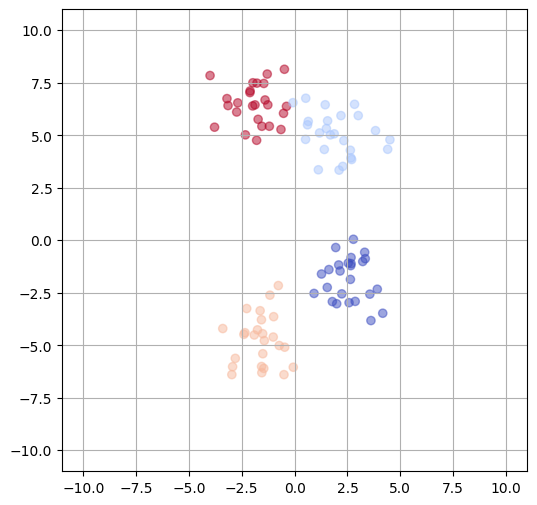

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

n_samples = 100
n_classes = 4

def generate_multiclass_dataset(n_samples, n_classes):
    X, y = make_blobs(n_samples=n_samples,
                      centers=n_classes,
                      n_features = 2,
                      center_box=(-7, 7),
                      cluster_std=1)
    return X, y

def plotDataset(X, y, xlim=(-11, 11), ylim=(-11, 11)):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', alpha=0.5, cmap="coolwarm")
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.grid(True)

def plotHyperplan(weights, bias):
    xs = np.array([-11, 11])
    ys = -(weights[0]*xs + bias)/weights[1]
    plt.plot(xs, ys, '--')

weights = np.random.rand(2)*2-1
bias = np.random.rand()*6-3
print(weights, bias)

X, y = generate_multiclass_dataset(n_samples, n_classes)
plotDataset(X, y)
plt.show()

In [2]:
print(y)

[2 3 3 0 2 1 0 3 1 0 2 0 2 0 3 1 2 3 1 3 2 2 3 3 1 2 2 0 1 3 0 2 2 3 0 1 2
 3 3 0 0 1 0 1 3 2 0 1 3 2 3 2 3 3 2 0 2 1 2 1 2 0 2 0 1 3 1 1 2 0 1 3 0 3
 0 0 1 3 2 0 0 3 2 1 0 3 1 2 1 1 2 0 0 1 0 3 3 1 1 1]


In [3]:
from abc import ABC, abstractmethod

class CostFunction(ABC):
    @abstractmethod
    def getCost(self, y, ypred):
        pass
    @abstractmethod
    def getGradient(self, X):
        pass

class WidrowHoff(CostFunction):
  def getCost(self, y, y_pred):
    return np.mean((y - y_pred)**2)
  def getGradient(self, y, y_pred, X):
    return X.T @ (y - y_pred)


In [10]:
class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class GradientDescent(TrainingAlgorithm):
  def __init__(self, max_iter=1000, learning_rate=0.001, cost=WidrowHoff()):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(size=(X.shape[1],y.shape[1]))
    for _ in range(self.max_iter):
      y_pred = X @ w
      w += self.cost.getGradient(y, y_pred, X) * self.learning_rate
    return w


In [5]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer()
label_binarizer.fit(y)
y_hot = label_binarizer.transform(y)
print(y)
# print(y_hot)

[2 3 3 0 2 1 0 3 1 0 2 0 2 0 3 1 2 3 1 3 2 2 3 3 1 2 2 0 1 3 0 2 2 3 0 1 2
 3 3 0 0 1 0 1 3 2 0 1 3 2 3 2 3 3 2 0 2 1 2 1 2 0 2 0 1 3 1 1 2 0 1 3 0 3
 0 0 1 3 2 0 0 3 2 1 0 3 1 2 1 1 2 0 0 1 0 3 3 1 1 1]


In [11]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelBinarizer
from pprint import pprint

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class ShallowNeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    self.label_binarizer = LabelBinarizer()
    y = self.label_binarizer.fit_transform(y)
    y = np.where(y == 1, 1, -1)
    X = include_bias(X)
    self.w = self.trainingAlgorithm.getW(X, y)
    return self

  def pre_activation(self, X):
    logits = X @ self.w
    return logits

  def predict(self, X):
    X = include_bias(X)
    y_pred = self.pre_activation(X)
    if y_pred.shape[1] == 1:
      y_pred = np.where(y_pred > 0, 1, -1)
    y_pred = self.label_binarizer.inverse_transform(y_pred)
    return y_pred

model = ShallowNeuralNetwork(GradientDescent())
model.fit(X, y)
y_pred = model.predict(X)
print(y_pred)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: ")
pprint(model.w)

[-1.  1. -1. -1.  1.  1. -1. -1. -1.  1.  1. -1. -1.  1. -1. -1.  1. -1.
 -1. -1.]
Accuracy: 0.9
Weights: 
array([[-0.00426803],
       [ 0.11448495],
       [-0.09020056]])


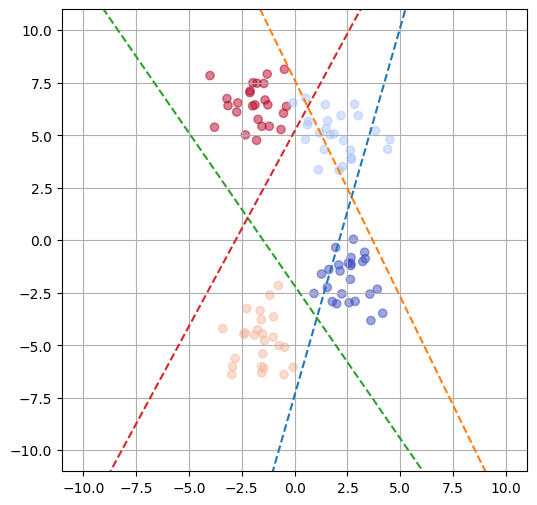

In [7]:
plotDataset(X, y)
for i in range(model.w.shape[1]):
  plotHyperplan(model.w[1:, i], model.w[0,i])
plt.show()

Accuracy: 1.0
Weights: 
array([[ 0.19336664],
       [ 0.3831406 ],
       [-0.42511985]])


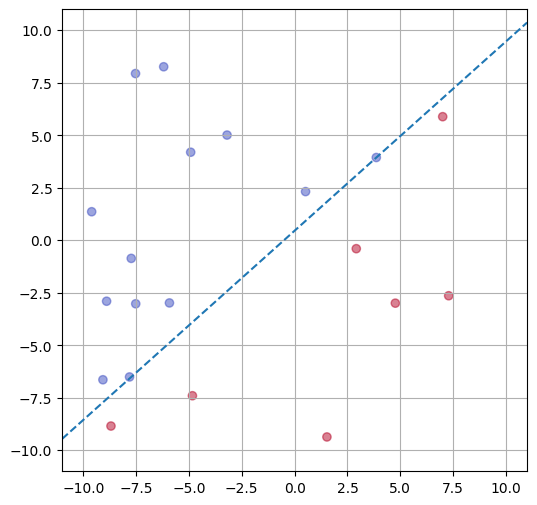

In [12]:
class SmoothSurrogate(CostFunction):
  def getCost(self, y, y_pred):
    error = y - np.sign(y_pred)
    return np.sqrt(np.sum(error**2))
  def getGradient(self, y, y_pred, X):
    error = y - np.sign(y_pred)
    return X.T @ error

model = ShallowNeuralNetwork(GradientDescent(cost=SmoothSurrogate()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: ")
pprint(model.w)
plotDataset(X, y)
for i in range(model.w.shape[1]):
  plotHyperplan(model.w[1:, i], model.w[0,i])
plt.show()

Accuracy: 0.9
Weights: 
array([[ 0.30431814],
       [ 0.27636781],
       [-0.28506043]])


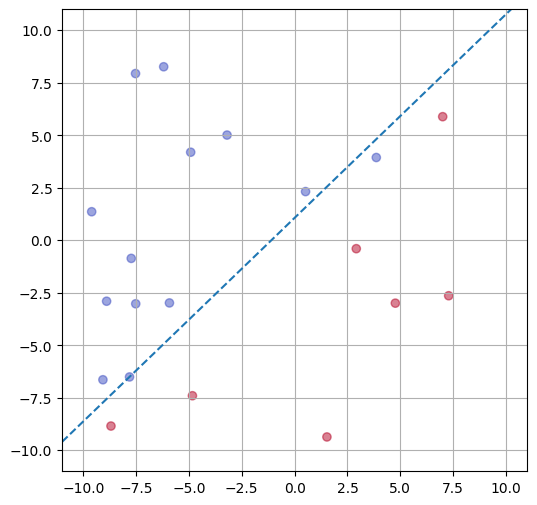

In [9]:
def generateLinearSeparableDataset(n_samples, weights, bias):
    n_features = len(weights)
    X = np.random.rand(n_samples, n_features)*20-10
    y = np.sign(np.dot(X, weights) + bias)
    return X, y

X, y = generateLinearSeparableDataset(20, [1, -1], 0)
model = ShallowNeuralNetwork(GradientDescent(cost=SmoothSurrogate()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: ")
pprint(model.w)
plotDataset(X, y)
for i in range(model.w.shape[1]):
  plotHyperplan(model.w[1:, i], model.w[0,i])
plt.show()